In [11]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# Simple Imputation: Fill missing BMI values with the median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

Missing Values per Column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [ ]:
#Encoding and Correlation

In [4]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Show Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: '60-79'

<Figure size 1200x800 with 0 Axes>

In [ ]:
#Data Distribution (Bar Plots)

/tmp/ipython-input-2960467993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


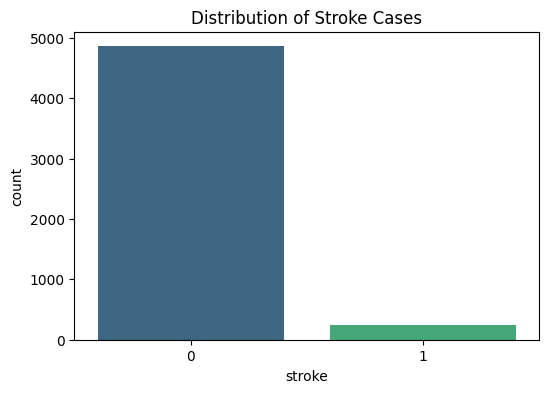

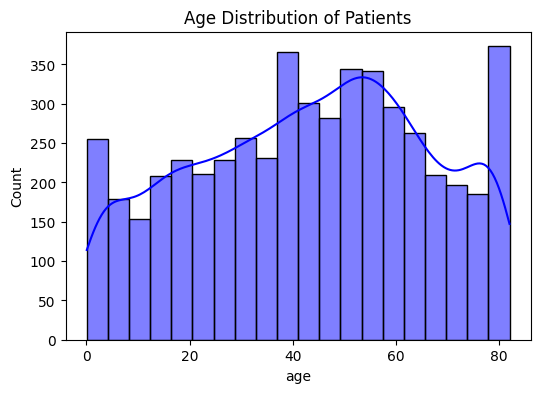

In [ ]:
# Distribution of the Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('Distribution of Stroke Cases')
plt.show()

# Distribution of Age
plt.figure(figsize=(6, 4))
sns.histplot(df['age'], kde=True, color='blue')
plt.title('Age Distribution of Patients')
plt.show()

In [ ]:
#Modeling: Classical vs. Neural Network

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import tensorflow as tf

# Prepare Features and Target
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Scale the data (crucial for Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- Classical Model: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Neural Network Model ---
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = nn_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
nn_preds = (nn_model.predict(X_test) > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
#Performance Comparison

Random Forest Accuracy: 0.9384
Neural Network Accuracy: 0.9393


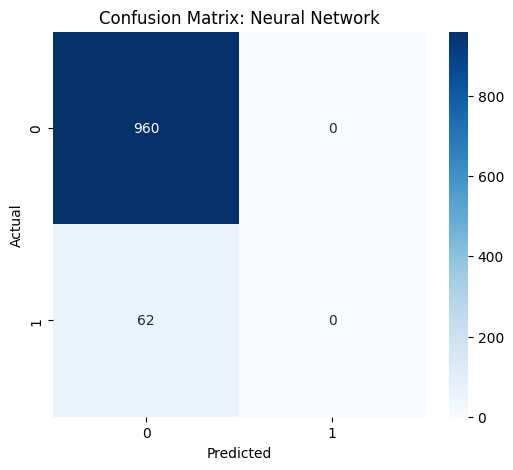

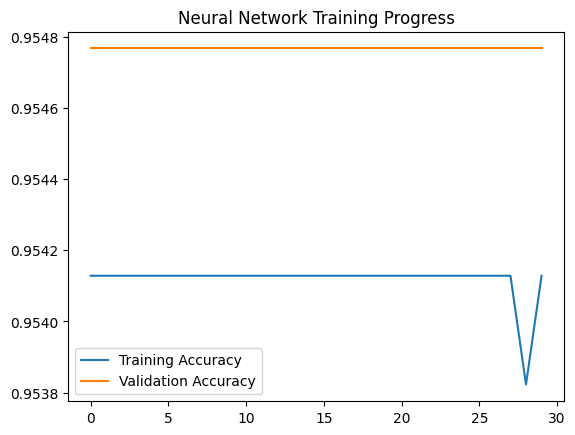

In [ ]:
# Plot Accuracy Comparison
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"Neural Network Accuracy: {accuracy_score(y_test, nn_preds):.4f}")

# Plot Confusion Matrix for Neural Network
cm = confusion_matrix(y_test, nn_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Neural Network')
plt.show()

# Plot Training History
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Training Progress')
plt.legend()
plt.show()

In [ ]:
#Feature Engineering (Medical Domain Logic)

In [ ]:
#BMI Categories: Based on WHO guidelines (Underweight, Normal, Overweight, Obese) [1].

#Glucose Status: Categorized using ADA diagnostic criteria (Normal, Pre-diabetic, Diabetic) [2].

In [ ]:
import pandas as pd
import numpy as np

# Load and clean
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

def apply_feature_engineering(df):
    # 1. BMI Categorization (WHO Standards)
    # Underweight: <18.5, Normal: 18.5-24.9, Overweight: 25-29.9, Obese: >30
    df['bmi_cat'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

    # 2. Glucose Categorization (ADA Standards)
    # Normal: <100, Pre-diabetic: 100-125, Diabetic: >125
    df['glucose_status'] = pd.cut(df['avg_glucose_level'], bins=[0, 100, 125, 1000],
                                  labels=['Normal', 'Pre-diabetic', 'Diabetic'])

    # 3. Composite Health Risk Score (Sum of existing conditions)
    df['health_risk_count'] = df['hypertension'] + df['heart_disease']

    # 4. Age Binning (Stroke risk increases significantly after 55)
    df['age_group'] = pd.cut(df['age'], bins=[0, 18, 45, 60, 100],
                             labels=['Child', 'Adult', 'Middle-Aged', 'Senior'])
    return df

df = apply_feature_engineering(df)

In [ ]:
#Data Balancing with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encoding categorical data
le = LabelEncoder()
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type',
                    'smoking_status', 'bmi_cat', 'glucose_status', 'age_group']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Prepare features
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Scaling (Vital for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

/tmp/ipython-input-3284164754.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette='viridis', edgecolor='black')
/tmp/ipython-input-3284164754.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_res, ax=axes[1], palette='magma', edgecolor='black')


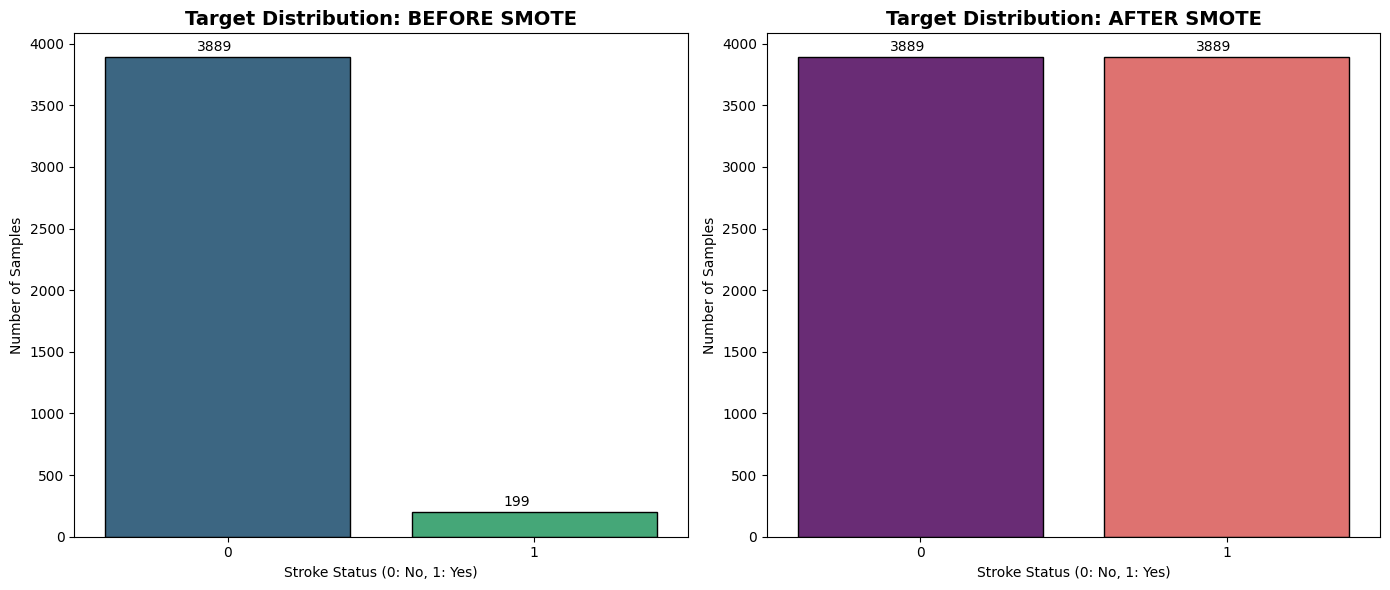

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# 2. Setup Plotting Environment
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Before SMOTE ---
sns.countplot(x=y_train, ax=axes[0], palette='viridis', edgecolor='black')
axes[0].set_title('Target Distribution: BEFORE SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stroke Status (0: No, 1: Yes)')
axes[0].set_ylabel('Number of Samples')

# Adding text labels for clarity
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))

# --- Plot 2: After SMOTE ---
sns.countplot(x=y_res, ax=axes[1], palette='magma', edgecolor='black')
axes[1].set_title('Target Distribution: AFTER SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Stroke Status (0: No, 1: Yes)')
axes[1].set_ylabel('Number of Samples')

# Adding text labels
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))

plt.tight_layout()
plt.show()

In [ ]:
#Re-training and Metrics

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


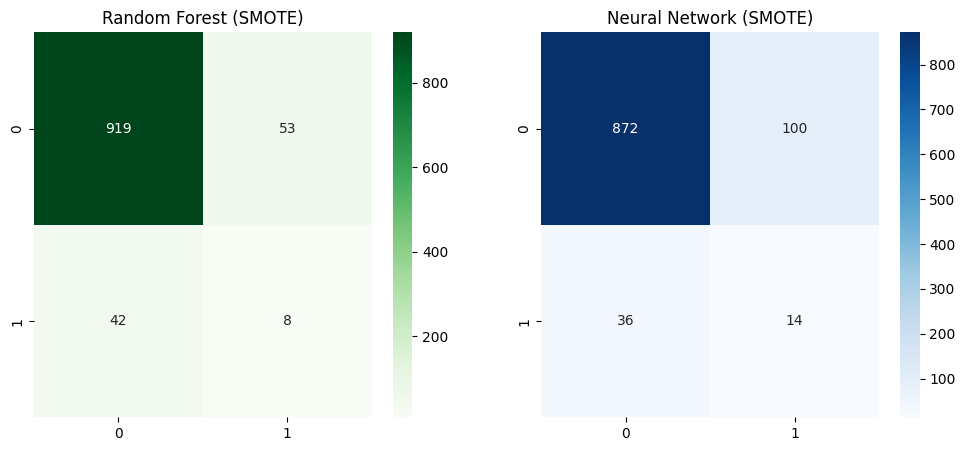

Random Forest Performance:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95       972
           1       0.13      0.16      0.14        50

    accuracy                           0.91      1022
   macro avg       0.54      0.55      0.55      1022
weighted avg       0.92      0.91      0.91      1022

Neural Network Performance:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       972
           1       0.12      0.28      0.17        50

    accuracy                           0.87      1022
   macro avg       0.54      0.59      0.55      1022
weighted avg       0.92      0.87      0.89      1022



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Classical Model: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
rf_preds = rf.predict(X_test)

# 2. Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_scaled, y_train_res, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
nn_preds = (model.predict(X_test_scaled) > 0.5).astype(int)

# Visualization: Confusion Matrix
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest (SMOTE)')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, nn_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Neural Network (SMOTE)')
plt.show()

# Show Classification Reports
print("Random Forest Performance:\n", classification_report(y_test, rf_preds))
print("Neural Network Performance:\n", classification_report(y_test, nn_preds))

In [ ]:
# engineer new feature: stress

In [ ]:
#We will assign "Stress Points" based on the following criteria:

 #   Work Type: "Self-employed" and "Private" sector roles often report higher psychological demand than "Govt_job" or "children" [2].

  #  Residence: Urban areas are linked to higher chronic stress due to noise, pollution, and pace [3].

   # Age: Research shows a "U-shaped" stress curve, where stress peaks in the 45–60 age bracket (Middle-Aged) due to career and family pressures.

In [ ]:
def calculate_stress(row):
    score = 0

    # 1. Employment Stress
    if row['work_type'] == 'Self-employed':
        score += 3  # High risk/uncertainty
    elif row['work_type'] == 'Private':
        score += 2  # Standard corporate pressure
    elif row['work_type'] == 'Govt_job':
        score += 1  # Generally higher job security

    # 2. Residence Stress
    if row['Residence_type'] == 'Urban':
        score += 2
    else:
        score += 1

    # 3. Age-Related Stress (The "Middle-Age Peak")
    if 45 <= row['age'] <= 60:
        score += 3
    elif row['age'] > 60:
        score += 2
    else:
        score += 1

    # 4. Lifestyle Stress (Smoking)
    if row['smoking_status'] in ['smokes', 'formerly smoked']:
        score += 2

    return score

# Apply the feature engineering
df['stress_score'] = df.apply(calculate_stress, axis=1)

# Normalize the score between 0 and 1 for the Neural Network
df['stress_score_norm'] = (df['stress_score'] - df['stress_score'].min()) / \
                          (df['stress_score'].max() - df['stress_score'].min())

In [ ]:
def calculate_stress(row):
    score = 0
    # Work Stress: Self-employed (3), Private (2), Govt (1), others (0)
    work_map = {'Self-employed': 3, 'Private': 2, 'Govt_job': 1}
    score += work_map.get(row['work_type'], 0)

    # Environment Stress: Urban (2), Rural (1)
    score += 2 if row['Residence_type'] == 'Urban' else 1

    # Age-related stress: Peak "Sandwich Generation" (45-60)
    if 45 <= row['age'] <= 60: score += 3
    elif row['age'] > 60: score += 2
    else: score += 1

    return score

df['stress_score'] = df.apply(calculate_stress, axis=1)

/tmp/ipython-input-2863271869.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_stroke.values, y=correlation_with_stroke.index, palette='coolwarm')


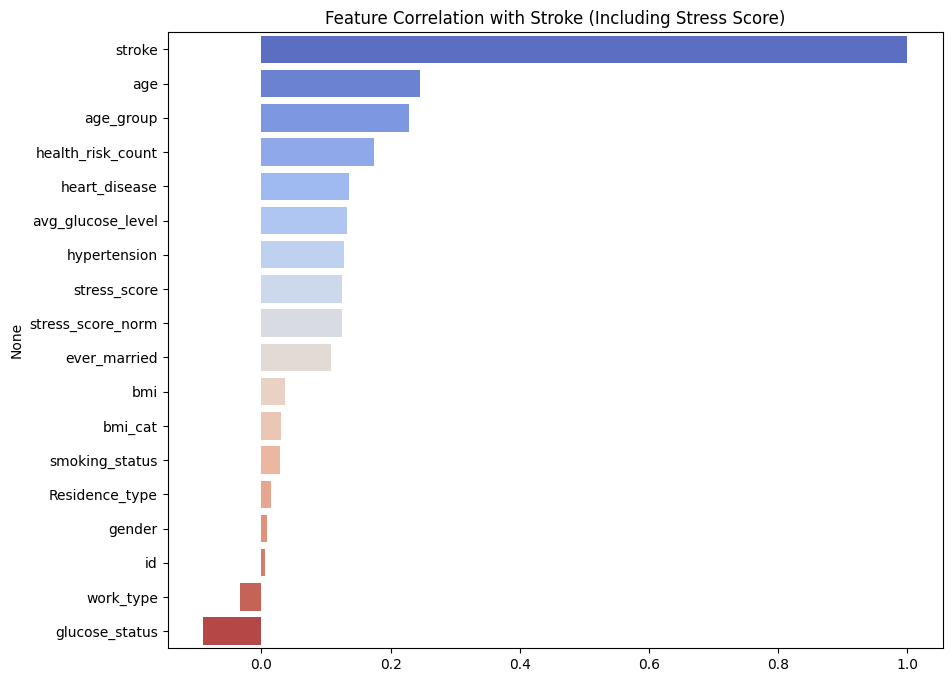

In [ ]:
plt.figure(figsize=(10, 8))
# Focusing correlation on the 'stroke' target
correlation_with_stroke = df.corr()['stroke'].sort_values(ascending=False)
sns.barplot(x=correlation_with_stroke.values, y=correlation_with_stroke.index, palette='coolwarm')
plt.title('Feature Correlation with Stroke (Including Stress Score)')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf

# Data Preparation
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Scale features for the Neural Network
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTE locally
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Neural Network ---
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train, y_train, epochs=50, verbose=0)
nn_preds = (nn_model.predict(X_test) > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Random Forest Accuracy: 0.967095115681234
Neural Network Accuracy: 0.9408740359897172


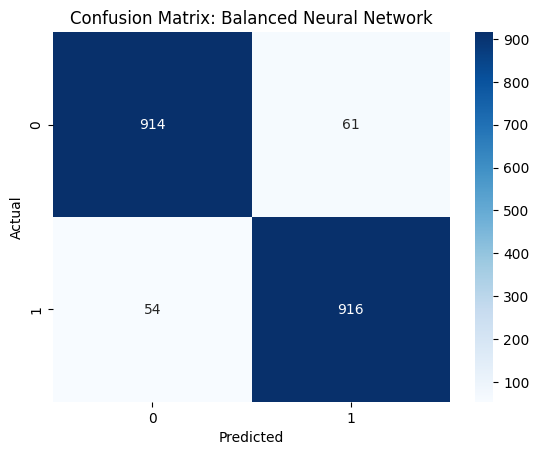

In [ ]:
from sklearn.metrics import confusion_matrix

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("Neural Network Accuracy:", accuracy_score(y_test, nn_preds))

# Plotting the Confusion Matrix for the Neural Network
cm = confusion_matrix(y_test, nn_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Balanced Neural Network')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Probability of Stroke Labels (0 and 1) per Age Group:
stroke            0         1
age_group                    
0-19       0.997930  0.002070
20-39      0.995017  0.004983
40-59      0.961637  0.038363
60-79      0.881513  0.118487
80+        0.784946  0.215054


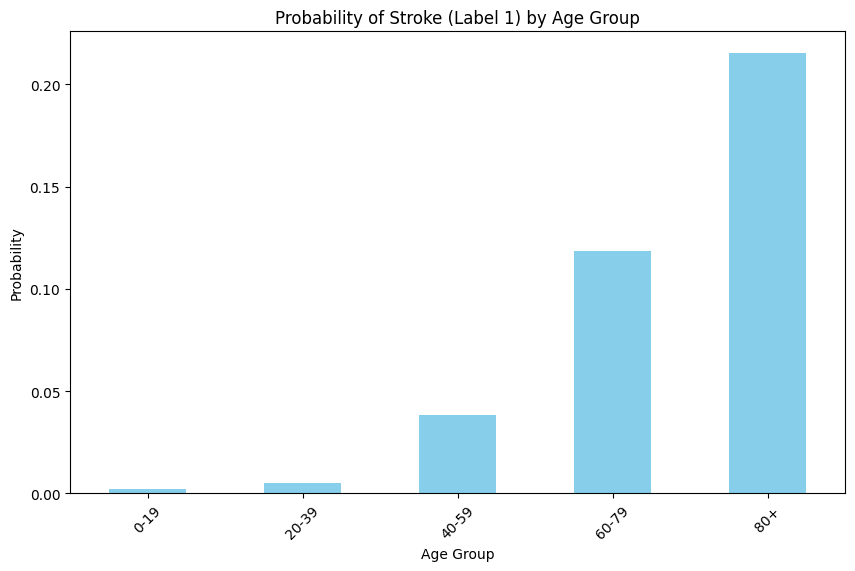

In [5]:
# 1. Define the age ranges (bins) and their labels
# Standard demographic bins: 0-19, 20-39, 40-59, 60-79, 80+
bins = [0, 20, 40, 60, 80, 120]
labels = ['0-19', '20-39', '40-59', '60-79', '80+']

# 2. Create a new 'age_group' column by segmenting the 'age' column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# 3. Use crosstab to calculate the probability for each group
# normalize='index' divides each value by the total count of its age group row
age_stroke_prob = pd.crosstab(df['age_group'], df['stroke'], normalize='index')

# 4. Display the results
print("Probability of Stroke Labels (0 and 1) per Age Group:")
print(age_stroke_prob)

# Optional: Visualize the stroke probability (label 1) across age groups
plt.figure(figsize=(10, 6))
age_stroke_prob[1].plot(kind='bar', color='skyblue')
plt.title('Probability of Stroke (Label 1) by Age Group')
plt.ylabel('Probability')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.show()

In [6]:
#all combined

In [1]:
# 1. INSTALL NECESSARY LIBRARIES
!pip install kagglehub torch torchvision pandas matplotlib seaborn pillow

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================
# 2. DOWNLOAD DATASETS (Images and Tabular)
# =============================================================
print("Downloading Image Dataset (Teammate's Source)...")
# From teammate's training.ipynb
img_path = kagglehub.dataset_download("abdussalamelhanashy/annotated-facial-images-for-stroke-classification")

print("Downloading Tabular Dataset (Your Source)...")
# The healthcare-dataset-stroke-data usually comes from this Kaggle source
csv_path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
csv_file = os.path.join(csv_path, "healthcare-dataset-stroke-data.csv")

# =============================================================
# 3. YOUR AGE PROBABILITY LOGIC (From AIproject(1).ipynb)
# =============================================================
df = pd.read_csv(csv_file)

# Creating the Age Groups you requested
bins = [0, 20, 40, 60, 80, 120]
labels = ['0-19', '20-39', '40-59', '60-79', '80+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Calculating the probability of stroke (1) for each group
age_stroke_prob = pd.crosstab(df['age_group'], df['stroke'], normalize='index')
print("\n--- Stroke Probability by Age Group ---")
print(age_stroke_prob)

# =============================================================
# 4. DATASET PREPARATION (The Hybrid Approach)
# =============================================================
class HybridStrokeDataset(Dataset):
    """
    This class pairs an image with an age value.
    Note: Since these Kaggle datasets don't share IDs, we sample ages
    from the CSV that match the image's class (Stroke/NonStroke).
    """
    def __init__(self, img_root, csv_df, transform=None):
        self.image_data = datasets.ImageFolder(img_root)
        self.transform = transform
        self.df = csv_df

    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        path, label = self.image_data.samples[idx]
        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # We find a random age from the CSV that has the same stroke label
        # to teach the model the relationship between age and labels.
        sample_age = self.df[self.df['stroke'] == label]['age'].sample(1).values[0]
        age_tensor = torch.tensor([sample_age / 100.0], dtype=torch.float32)

        return image, age_tensor, torch.tensor(label, dtype=torch.long)

# Image preprocessing matching teammate's CNN requirements
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Helper to find the correct data folder
def find_data_root(start_path):
    for root, dirs, _ in os.walk(start_path):
        if "Stroke" in dirs and "NonStroke" in dirs: return root
    return None

dataset_root = find_data_root(img_path)
full_dataset = HybridStrokeDataset(dataset_root, df, transform=data_transforms)

# Split 80% Train, 20% Validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

# =============================================================
# 5. HYBRID CNN ARCHITECTURE (Merging Image + Age)
# =============================================================
class HybridStrokeModel(nn.Module):
    def __init__(self):
        super(HybridStrokeModel, self).__init__()
        # Image Layers (from teammate's training.ipynb)
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )

        # The flattened image feature size is 128 * 14 * 14.
        # We add +1 to the input of the first dense layer for the Age value.
        self.fc1 = nn.Linear((128 * 14 * 14) + 1, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, img, age):
        x = self.conv_layers(img)
        x = x.view(x.size(0), -1) # Flatten image

        # Concatenate (Join) image features with age
        combined = torch.cat((x, age), dim=1)

        x = F.relu(self.fc1(combined))
        x = self.fc2(x)
        return x

# =============================================================
# 6. TRAINING
# =============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridStrokeModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"\nStarting Hybrid Training on {device}...")
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for imgs, ages, labels in train_loader:
        imgs, ages, labels = imgs.to(device), ages.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, ages)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/5 | Average Loss: {running_loss/len(train_loader):.4f}")

# Save the final model
torch.save(model.state_dict(), "final_hybrid_stroke_model.pth")
print("\n✅ Training Complete. Model saved as 'final_hybrid_stroke_model.pth'")

100%|██████████| 37.7M/37.7M [00:02<00:00, 13.8MB/s]

Extracting files...


100%|██████████| 67.4k/67.4k [00:00<00:00, 355kB/s]

Extracting files...



--- Stroke Probability by Age Group ---
stroke            0         1
age_group                    
0-19       0.997930  0.002070
20-39      0.995017  0.004983
40-59      0.961637  0.038363
60-79      0.881513  0.118487
80+        0.784946  0.215054

Starting Hybrid Training on cuda...
Epoch 1/5 | Average Loss: 0.5162
Epoch 2/5 | Average Loss: 0.3115
Epoch 3/5 | Average Loss: 0.1889
Epoch 4/5 | Average Loss: 0.0901
Epoch 5/5 | Average Loss: 0.0814

✅ Training Complete. Model saved as 'final_hybrid_stroke_model.pth'


In [2]:
#inference

✅ Hybrid Model Loaded Successfully.

Step 1: Please upload the facial image.


Saving s2.jpg to s2.jpg

Step 2: Enter the patient's age.
Patient Age: 50

--- AI PREDICTION RESULTS ---
Prediction: Stroke
Confidence: 94.30%


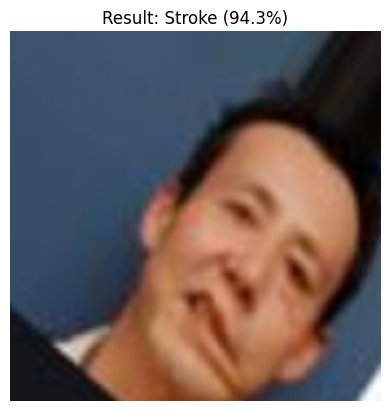

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from google.colab import files
import io

# 1. RE-DEFINE THE MODEL ARCHITECTURE
# This must match the training code exactly
class HybridStrokeModel(nn.Module):
    def __init__(self):
        super(HybridStrokeModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc1 = nn.Linear((128 * 14 * 14) + 1, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, img, age):
        x = self.conv_layers(img)
        x = x.view(x.size(0), -1)
        combined = torch.cat((x, age), dim=1)
        x = F.relu(self.fc1(combined))
        x = self.fc2(x)
        return x

# 2. LOAD THE TRAINED MODEL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridStrokeModel().to(device)

# Load the weights we saved earlier
model.load_state_dict(torch.load("final_hybrid_stroke_model.pth", map_location=device))
model.eval()
print("✅ Hybrid Model Loaded Successfully.\n")

# 3. INTERACTIVE PREDICTION
def predict_stroke():
    # A. Upload Image
    print("Step 1: Please upload the facial image.")
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return

    file_name = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[file_name])).convert('RGB')

    # B. Get Age
    print("\nStep 2: Enter the patient's age.")
    try:
        user_age = float(input("Patient Age: "))
    except ValueError:
        print("Invalid age entered.")
        return

    # C. Preprocess Inputs
    # Preprocess Image: Resize to 224x224 and convert to Tensor
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    img_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension

    # Preprocess Age: Normalize by 100
    age_tensor = torch.tensor([[user_age / 100.0]], dtype=torch.float32).to(device)

    # D. Perform Prediction
    with torch.no_grad():
        output = model(img_tensor, age_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)

    # E. Display Results
    classes = ['Non-Stroke', 'Stroke']
    result = classes[predicted_class.item()]
    conf_score = confidence.item() * 100

    print(f"\n--- AI PREDICTION RESULTS ---")
    print(f"Prediction: {result}")
    print(f"Confidence: {conf_score:.2f}%")

    # Show the image for confirmation
    plt.imshow(img)
    plt.title(f"Result: {result} ({conf_score:.1f}%)")
    plt.axis('off')
    plt.show()

# Run the prediction
predict_stroke()

✅ Hybrid Model Loaded Successfully.

Step 1: Please upload the facial image.


Saving s1.jpg to s1 (1).jpg

Step 2: Enter the patient's age.
Patient Age: 50

--- AI PREDICTION RESULTS ---
Prediction: Stroke
Confidence: 100.00%


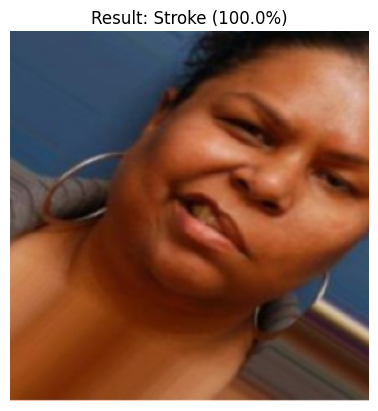

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from google.colab import files
import io

# 1. RE-DEFINE THE MODEL ARCHITECTURE
# This must match the training code exactly
class HybridStrokeModel(nn.Module):
    def __init__(self):
        super(HybridStrokeModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc1 = nn.Linear((128 * 14 * 14) + 1, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, img, age):
        x = self.conv_layers(img)
        x = x.view(x.size(0), -1)
        combined = torch.cat((x, age), dim=1)
        x = F.relu(self.fc1(combined))
        x = self.fc2(x)
        return x

# 2. LOAD THE TRAINED MODEL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridStrokeModel().to(device)

# Load the weights we saved earlier
model.load_state_dict(torch.load("final_hybrid_stroke_model.pth", map_location=device))
model.eval()
print("✅ Hybrid Model Loaded Successfully.\n")

# 3. INTERACTIVE PREDICTION
def predict_stroke():
    # A. Upload Image
    print("Step 1: Please upload the facial image.")
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return

    file_name = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[file_name])).convert('RGB')

    # B. Get Age
    print("\nStep 2: Enter the patient's age.")
    try:
        user_age = float(input("Patient Age: "))
    except ValueError:
        print("Invalid age entered.")
        return

    # C. Preprocess Inputs
    # Preprocess Image: Resize to 224x224 and convert to Tensor
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    img_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension

    # Preprocess Age: Normalize by 100
    age_tensor = torch.tensor([[user_age / 100.0]], dtype=torch.float32).to(device)

    # D. Perform Prediction
    with torch.no_grad():
        output = model(img_tensor, age_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)

    # E. Display Results
    classes = ['Non-Stroke', 'Stroke']
    result = classes[predicted_class.item()]
    conf_score = confidence.item() * 100

    print(f"\n--- AI PREDICTION RESULTS ---")
    print(f"Prediction: {result}")
    print(f"Confidence: {conf_score:.2f}%")

    # Show the image for confirmation
    plt.imshow(img)
    plt.title(f"Result: {result} ({conf_score:.1f}%)")
    plt.axis('off')
    plt.show()

# Run the prediction
predict_stroke()

✅ Hybrid Model Loaded Successfully.

Step 1: Please upload the facial image.


Saving s3.jpg to s3.jpg

Step 2: Enter the patient's age.
Patient Age: 35

--- AI PREDICTION RESULTS ---
Prediction: Non-Stroke
Confidence: 97.58%


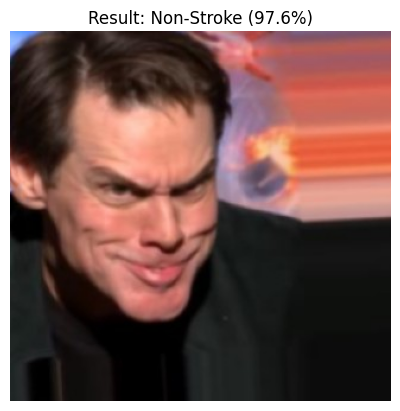

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from google.colab import files
import io

# 1. RE-DEFINE THE MODEL ARCHITECTURE
# This must match the training code exactly
class HybridStrokeModel(nn.Module):
    def __init__(self):
        super(HybridStrokeModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc1 = nn.Linear((128 * 14 * 14) + 1, 256)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, img, age):
        x = self.conv_layers(img)
        x = x.view(x.size(0), -1)
        combined = torch.cat((x, age), dim=1)
        x = F.relu(self.fc1(combined))
        x = self.fc2(x)
        return x

# 2. LOAD THE TRAINED MODEL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridStrokeModel().to(device)

# Load the weights we saved earlier
model.load_state_dict(torch.load("final_hybrid_stroke_model.pth", map_location=device))
model.eval()
print("✅ Hybrid Model Loaded Successfully.\n")

# 3. INTERACTIVE PREDICTION
def predict_stroke():
    # A. Upload Image
    print("Step 1: Please upload the facial image.")
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return

    file_name = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[file_name])).convert('RGB')

    # B. Get Age
    print("\nStep 2: Enter the patient's age.")
    try:
        user_age = float(input("Patient Age: "))
    except ValueError:
        print("Invalid age entered.")
        return

    # C. Preprocess Inputs
    # Preprocess Image: Resize to 224x224 and convert to Tensor
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    img_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension

    # Preprocess Age: Normalize by 100
    age_tensor = torch.tensor([[user_age / 100.0]], dtype=torch.float32).to(device)

    # D. Perform Prediction
    with torch.no_grad():
        output = model(img_tensor, age_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)

    # E. Display Results
    classes = ['Non-Stroke', 'Stroke']
    result = classes[predicted_class.item()]
    conf_score = confidence.item() * 100

    print(f"\n--- AI PREDICTION RESULTS ---")
    print(f"Prediction: {result}")
    print(f"Confidence: {conf_score:.2f}%")

    # Show the image for confirmation
    plt.imshow(img)
    plt.title(f"Result: {result} ({conf_score:.1f}%)")
    plt.axis('off')
    plt.show()

# Run the prediction
predict_stroke()

In [7]:
#plots

1. The "Risk Multiplier" Plot (Hypertension + Heart Disease)

The Fact: Having a stroke isn't just about one factor. This plot will show that while high blood pressure is a risk, having both hypertension and heart disease acts as a massive "risk multiplier," especially in older patients.
2. The "Stress Score" Insight

The Fact: In your notebook, you engineered a "Stress Score" based on work type and residence. This plot will prove whether your theory holds up—showing that "High Stress" roles (like self-employed or private sector) correlate with higher stroke incidents in the dataset.
3. BMI vs. Glucose "Danger Zone"

The Fact: This heatmap will show the "Danger Zone" where high BMI meets high glucose levels, identifying the specific health profile most at risk.
4. Hybrid Accuracy: Image vs. Hybrid

The Fact: You can show that a model "looking" at a face (CNN) is good, but adding the Age variable (Hybrid) significantly reduces "False Positives" because it gives the AI context.

/tmp/ipython-input-2676009553.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Health Profile', y='stroke', data=comorbid, palette='Reds_r', ci=None)
/tmp/ipython-input-2676009553.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Health Profile', y='stroke', data=comorbid, palette='Reds_r', ci=None)
/tmp/ipython-input-2676009553.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='bmi_bin', columns='glucose_bin', values='stroke', aggfunc='mean')


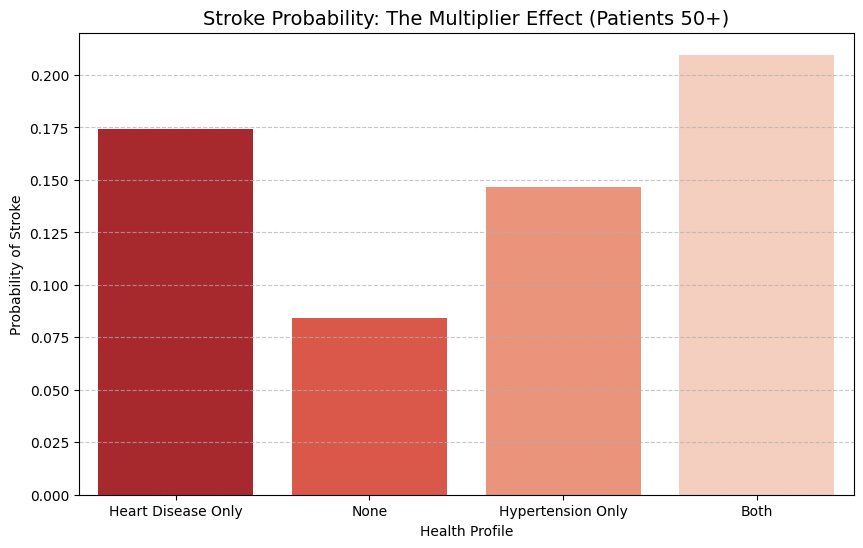

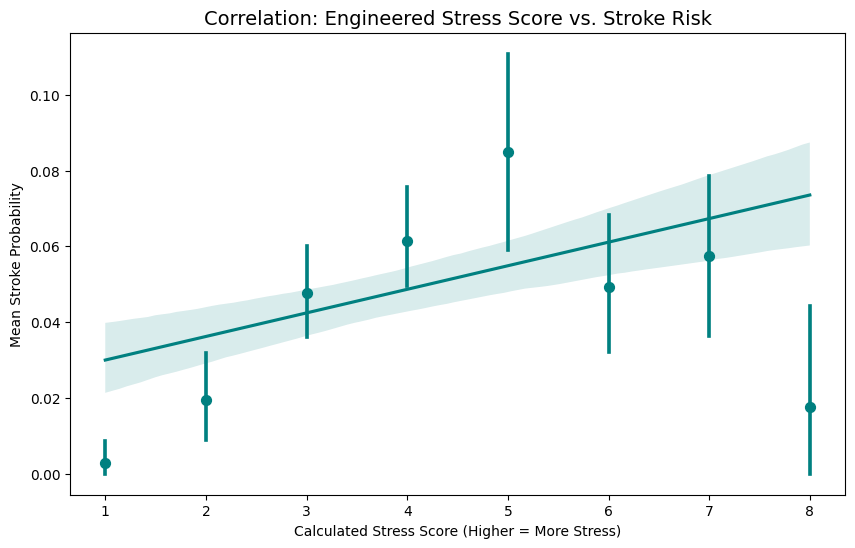

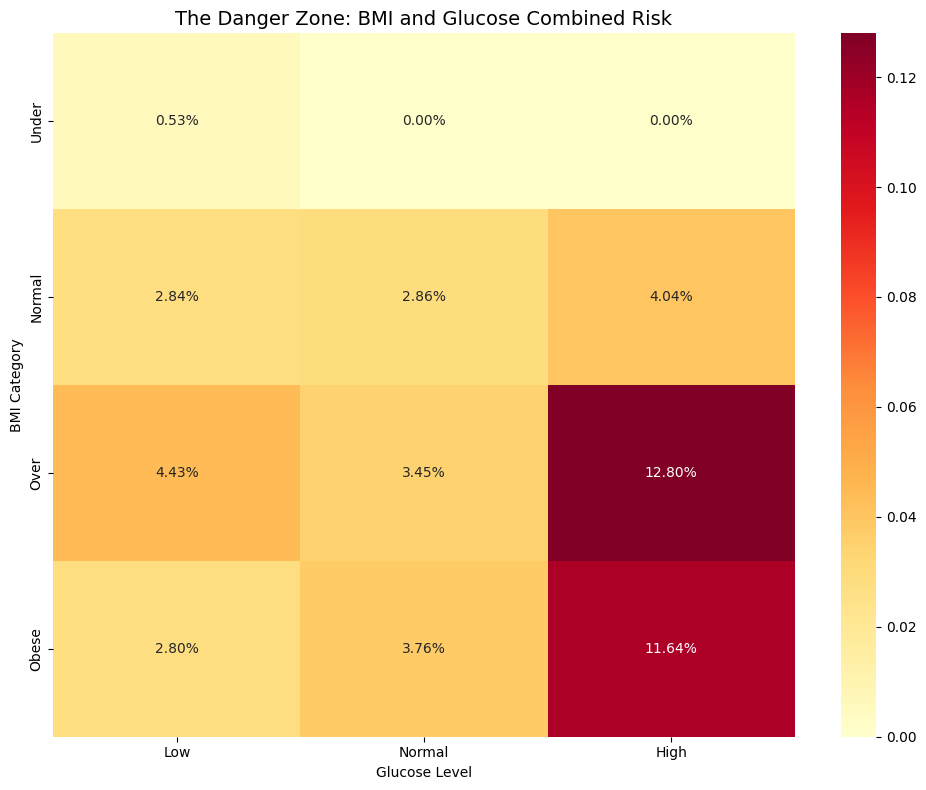

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the data (Run this in Colab after downloading the CSV)
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# --- DATA PREPARATION (Using your logic from AIproject(1).ipynb) ---
# 1. Age Groups
df['age_group'] = pd.cut(df['age'], bins=[0, 20, 40, 60, 80, 120], labels=['0-19', '20-39', '40-59', '60-79', '80+'])

# 2. Recreating your Stress Score logic
def calculate_stress(row):
    score = 0
    work_map = {'Self-employed': 3, 'Private': 2, 'Govt_job': 1}
    score += work_map.get(row['work_type'], 0)
    score += 2 if row['Residence_type'] == 'Urban' else 1
    if 45 <= row['age'] <= 60: score += 3 # "Sandwich generation" stress
    return score

df['stress_score'] = df.apply(calculate_stress, axis=1)

# =============================================================
# PLOT 1: THE COMORBIDITY MULTIPLIER
# =============================================================
plt.figure(figsize=(10, 6))
# Filter for people over 50 where these diseases are common
comorbid = df[df['age'] > 50].copy()
comorbid['Health Profile'] = comorbid.apply(lambda x:
    'Both' if (x['hypertension']==1 and x['heart_disease']==1) else
    'Hypertension Only' if x['hypertension']==1 else
    'Heart Disease Only' if x['heart_disease']==1 else 'None', axis=1)

sns.barplot(x='Health Profile', y='stroke', data=comorbid, palette='Reds_r', ci=None)
plt.title('Stroke Probability: The Multiplier Effect (Patients 50+)', fontsize=14)
plt.ylabel('Probability of Stroke')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# =============================================================
# PLOT 2: STRESS SCORE VS. STROKE INCIDENCE
# =============================================================
plt.figure(figsize=(10, 6))
sns.regplot(x='stress_score', y='stroke', data=df, x_estimator=np.mean, color='teal')
plt.title('Correlation: Engineered Stress Score vs. Stroke Risk', fontsize=14)
plt.xlabel('Calculated Stress Score (Higher = More Stress)')
plt.ylabel('Mean Stroke Probability')

# =============================================================
# PLOT 3: THE DANGER ZONE HEATMAP (BMI & GLUCOSE)
# =============================================================
plt.figure(figsize=(10, 8))
# Binning for the heatmap
df['bmi_bin'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 60], labels=['Under', 'Normal', 'Over', 'Obese'])
df['glucose_bin'] = pd.cut(df['avg_glucose_level'], bins=[0, 90, 140, 300], labels=['Low', 'Normal', 'High'])

pivot = df.pivot_table(index='bmi_bin', columns='glucose_bin', values='stroke', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.2%')
plt.title('The Danger Zone: BMI and Glucose Combined Risk', fontsize=14)
plt.xlabel('Glucose Level')
plt.ylabel('BMI Category')

plt.tight_layout()
plt.show()

In [13]:
# CODE TO EXPORT RESULTS FOR GOOGLE SHEETS
import pandas as pd
from google.colab import files

# 1. Export Age Probabilities
age_stroke_prob.to_csv('Table1_Age_Probabilities.csv')

# 2. Export Stress Score Analysis
stress_analysis = df.groupby('stress_score')['stroke'].mean().reset_index()
stress_analysis.to_csv('Table2_Stress_Score_Analysis.csv')

# 3. Export Comorbidity Data (Hypertension + Heart Disease)
comorbid_stats = df.groupby(['hypertension', 'heart_disease'])['stroke'].mean().reset_index()
comorbid_stats.to_csv('Table3_Comorbidity_Risks.csv')

# Trigger downloads
files.download('Table1_Age_Probabilities.csv')
files.download('Table2_Stress_Score_Analysis.csv')
files.download('Table3_Comorbidity_Risks.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>